In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
season_urls = {
    2008:"https://www.cricbuzz.com/cricket-series/2170/indian-premier-league-2013/stats?statsType=mostRuns&seasonSeriesId=2058&matchFormat=3",
    2009:"https://www.cricbuzz.com/cricket-series/7607/indian-premier-league-2024/stats?statsType=mostRuns&seasonSeriesId=2059&matchFormat=3",
    2010:"https://www.cricbuzz.com/cricket-series/7607/indian-premier-league-2024/stats?statsType=mostRuns&seasonSeriesId=2060&matchFormat=3",
    2011:"https://www.cricbuzz.com/cricket-series/7607/indian-premier-league-2024/stats?statsType=mostRuns&seasonSeriesId=2037&matchFormat=3",
    2012:"https://www.cricbuzz.com/cricket-series/7607/indian-premier-league-2024/stats?statsType=mostRuns&seasonSeriesId=2115&matchFormat=3",
    2013: "https://www.cricbuzz.com/cricket-series/2170/indian-premier-league-2013/stats",
    2014: "https://www.cricbuzz.com/cricket-series/2261/indian-premier-league-2014/stats",
    2015: "https://www.cricbuzz.com/cricket-series/2330/indian-premier-league-2015-ipl/stats",
    2016: "https://www.cricbuzz.com/cricket-series/2430/indian-premier-league-2016/stats",
    2017: "https://www.cricbuzz.com/cricket-series/2568/indian-premier-league-2017/stats",
    2018: "https://www.cricbuzz.com/cricket-series/2676/indian-premier-league-2018-ipl/stats",
    2019: "https://www.cricbuzz.com/cricket-series/2810/indian-premier-league-2019/stats",
    2020: "https://www.cricbuzz.com/cricket-series/3130/indian-premier-league-2020-ipl/stats",
    2021: "https://www.cricbuzz.com/cricket-series/3472/indian-premier-league-2021/stats",
    2022: "https://www.cricbuzz.com/cricket-series/4061/indian-premier-league-2022/stats",
    2023:"https://www.cricbuzz.com/cricket-series/7607/indian-premier-league-2024/stats?statsType=mostRuns&seasonSeriesId=5945&matchFormat=3",
    2024:"https://www.cricbuzz.com/cricket-series/7607/indian-premier-league-2024/stats?statsType=mostRuns&seasonSeriesId=7607&matchFormat=3",
    2025:"https://www.cricbuzz.com/cricket-series/7607/indian-premier-league-2024/stats?statsType=mostRuns&seasonSeriesId=9237&matchFormat=3",
    2026:"https://www.cricbuzz.com/cricket-series/7607/indian-premier-league-2024/stats?statsType=mostRuns&seasonSeriesId=9241&matchFormat=3"
    
}

print("Number of seasons:", len(season_urls))

Number of seasons: 19


In [4]:
url = "https://www.cricbuzz.com/cricket-series/4061/indian-premier-league-2022/stats"

response = requests.get(
    url,
    headers={
        "User-Agent": "Mozilla/5.0"
    }
)

print("Status Code:", response.status_code)

Status Code: 200


In [5]:
tables = pd.read_html(response.text)

# print("Number of tables:", len(tables))

C:\Users\navee\AppData\Local\Temp\ipykernel_21592\240337698.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [8]:
for i, table in enumerate(tables):

    # print("\nTABLE:", i)
    # print("Shape:", table.shape)
    # print("Columns:", table.columns.tolist())
    
    display(table.head())

,PLAYER,MATCHES,INNS,RUNS,AVG,SR,4s,6s
0,Jos Buttler,17,17,863,57.53,149.05,83,45
1,KL Rahul,15,15,616,51.33,135.38,45,30
2,Quinton de Kock,15,15,508,36.29,148.97,47,23
3,Hardik Pandya,15,15,487,44.27,131.27,49,12
4,Shubman Gill,16,16,483,34.50,132.33,51,11


In [9]:
batting_table = None

for table in tables:

    columns = [
        str(col).strip().upper()
        for col in table.columns
    ]

    if (
        "PLAYER" in columns
        and "RUNS" in columns
        and "AVG" in columns
        and "SR" in columns
    ):
        batting_table = table
        break

if batting_table is not None:

    print("Most Runs table found")
    print("Shape:", batting_table.shape)
    print("Columns:", batting_table.columns.tolist())

else:

    print("Most Runs table not found")

Most Runs table found
Shape: (15, 8)
Columns: ['PLAYER', 'MATCHES', 'INNS', 'RUNS', 'AVG', 'SR', '4s', '6s']


In [10]:
display(batting_table.head(10))

,PLAYER,MATCHES,INNS,RUNS,AVG,SR,4s,6s
0,Jos Buttler,17,17,863,57.53,149.05,83,45
1,KL Rahul,15,15,616,51.33,135.38,45,30
2,Quinton de Kock,15,15,508,36.29,148.97,47,23
3,Hardik Pandya,15,15,487,44.27,131.27,49,12
4,Shubman Gill,16,16,483,34.50,132.33,51,11
5,David Miller,16,16,481,68.71,142.73,32,23
6,Faf du Plessis,16,16,468,31.20,127.52,49,13
7,Shikhar Dhawan,14,14,460,38.33,122.67,47,12
8,Sanju Samson,17,17,458,28.62,146.79,43,26
9,Deepak Hooda,15,14,451,32.21,136.67,36,18


In [96]:
print("Number of columns:", len(batting_table.columns))

Number of columns: 8


In [97]:
batting_table.columns = [
    "Player",
    "Matches",
    "Innings",
    "Runs",
    "Average",
    "Strike_Rate",
    "Fours",
    "Sixes"
]

In [98]:
print(batting_table.columns)

Index(['Player', 'Matches', 'Innings', 'Runs', 'Average', 'Strike_Rate',
       'Fours', 'Sixes'],
      dtype='object')


In [99]:
batting_table["Season"] = 2022

In [100]:
display(batting_table.head())

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season
0,Jos Buttler,17,17,863,57.53,149.05,83,45,2022
1,KL Rahul,15,15,616,51.33,135.38,45,30,2022
2,Quinton de Kock,15,15,508,36.29,148.97,47,23,2022
3,Hardik Pandya,15,15,487,44.27,131.27,49,12,2022
4,Shubman Gill,16,16,483,34.50,132.33,51,11,2022


In [101]:
def scrape_ipl_season(url, season):

    try:

        response = requests.get(
            url,
            headers={
                "User-Agent": "Mozilla/5.0"
            },
            timeout=20
        )

        print(
            "Season:",
            season,
            "| Status:",
            response.status_code
        )

        if response.status_code != 200:
            return None

        tables = pd.read_html(response.text)

        batting_table = None

        for table in tables:

            columns = [
                str(col).strip().upper()
                for col in table.columns
            ]

            if (
                "PLAYER" in columns
                and "RUNS" in columns
                and "AVG" in columns
                and "SR" in columns
            ):

                batting_table = table
                break

        if batting_table is None:

            print("Most Runs table not found:", season)
            return None

        if len(batting_table.columns) != 8:

            print(
                "Unexpected number of columns:",
                len(batting_table.columns),
                "Season:",
                season
            )

            return None

        batting_table.columns = [
            "Player",
            "Matches",
            "Innings",
            "Runs",
            "Average",
            "Strike_Rate",
            "Fours",
            "Sixes"
        ]

        batting_table["Season"] = season

        return batting_table

    except Exception as e:

        print("Error in season", season, ":", e)

        return None

In [102]:
test_df = scrape_ipl_season(
    season_urls[2022],
    2022
)

display(test_df.head())

Season: 2022 | Status: 200


C:\Users\navee\AppData\Local\Temp\ipykernel_9992\591846504.py:23: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season
0,Jos Buttler,17,17,863,57.53,149.05,83,45,2022
1,KL Rahul,15,15,616,51.33,135.38,45,30,2022
2,Quinton de Kock,15,15,508,36.29,148.97,47,23,2022
3,Hardik Pandya,15,15,487,44.27,131.27,49,12,2022
4,Shubman Gill,16,16,483,34.50,132.33,51,11,2022


In [28]:
all_data = []

for season, url in season_urls.items():

    data = scrape_ipl_season(
        url,
        season
    )

    if data is not None:

        all_data.append(data)

Season: 2008 | Status: 200


C:\Users\navee\AppData\Local\Temp\ipykernel_9992\591846504.py:23: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Season: 2009 | Status: 200


C:\Users\navee\AppData\Local\Temp\ipykernel_9992\591846504.py:23: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Season: 2010 | Status: 200


...

C:\Users\navee\AppData\Local\Temp\ipykernel_9992\591846504.py:23: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Season: 2025 | Status: 200


C:\Users\navee\AppData\Local\Temp\ipykernel_9992\591846504.py:23: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Season: 2026 | Status: 200


C:\Users\navee\AppData\Local\Temp\ipykernel_9992\591846504.py:23: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [29]:
df = pd.concat(
    all_data,
    ignore_index=True
)

In [30]:
display(df.head(10))

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season
0,Shaun Marsh,11,11,616,68.44,139.68,59,26,2008
1,Gautam Gambhir,14,14,534,41.08,140.90,68,8,2008
2,Sanath Jayasuriya,14,14,514,42.83,166.34,57,31,2008
3,Shane Watson,15,15,472,47.20,151.77,47,19,2008
4,Graeme Smith,11,11,441,49.00,121.82,54,8,2008
5,Adam Gilchrist,14,14,436,33.54,137.11,51,19,2008
6,Yusuf Pathan,16,15,435,31.07,179.01,43,25,2008
7,Suresh Raina,16,14,421,38.27,142.71,35,18,2008
8,MS Dhoni,16,14,414,41.40,133.55,38,15,2008
9,Virender Sehwag,14,14,406,33.83,184.55,46,21,2008


In [31]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 285
Columns: 9


In [32]:
print(df.columns.tolist())

['Player', 'Matches', 'Innings', 'Runs', 'Average', 'Strike_Rate', 'Fours', 'Sixes', 'Season']


In [33]:
df["Season"].value_counts().sort_index()

Season
2008    15
2009    15
2010    15
2011    15
2012    15
2013    15
2014    15
2015    15
2016    15
2017    15
2018    15
2019    15
2020    15
2021    15
2022    15
2023    15
2024    15
2025    15
2026    15
Name: count, dtype: int64

In [34]:
print("Total rows collected:", len(df))

Total rows collected: 285


In [35]:
df.to_csv(
    "ipl_raw_data.csv",
    index=False
)

print("Raw CSV created successfully")

Raw CSV created successfully


In [36]:
df.head()

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season
0,Shaun Marsh,11,11,616,68.44,139.68,59,26,2008
1,Gautam Gambhir,14,14,534,41.08,140.90,68,8,2008
2,Sanath Jayasuriya,14,14,514,42.83,166.34,57,31,2008
3,Shane Watson,15,15,472,47.20,151.77,47,19,2008
4,Graeme Smith,11,11,441,49.00,121.82,54,8,2008


In [37]:
df.tail()

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season
280,Dhruv Jurel,16,16,515,36.79,154.65,47,24,2026
281,Prabhsimran Singh,14,13,510,42.50,168.87,55,23,2026
282,Rajat Patidar,15,14,501,41.75,192.69,30,42,2026
283,Shreyas Iyer,14,13,498,55.33,168.81,39,30,2026
284,Cooper Connolly,14,13,491,44.64,163.12,43,32,2026


In [38]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 285
Columns: 9


In [39]:
df.columns

Index(['Player', 'Matches', 'Innings', 'Runs', 'Average', 'Strike_Rate',
       'Fours', 'Sixes', 'Season'],
      dtype='object')

In [40]:
df.dtypes

Player          object
Matches          int64
Innings          int64
Runs             int64
Average        float64
Strike_Rate    float64
Fours            int64
Sixes            int64
Season           int64
dtype: object

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player       285 non-null    object 
 1   Matches      285 non-null    int64  
 2   Innings      285 non-null    int64  
 3   Runs         285 non-null    int64  
 4   Average      285 non-null    float64
 5   Strike_Rate  285 non-null    float64
 6   Fours        285 non-null    int64  
 7   Sixes        285 non-null    int64  
 8   Season       285 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 20.2+ KB


In [42]:
df.isnull().sum()


Player         0
Matches        0
Innings        0
Runs           0
Average        0
Strike_Rate    0
Fours          0
Sixes          0
Season         0
dtype: int64

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.describe()

,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season
count,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.00000
mean,14.852632,14.547368,489.659649,40.718912,143.153860,46.403509,20.263158,2017.00000
std,1.603046,1.623562,106.845979,10.847352,20.649265,13.932255,10.066900,5.48686
min,8.000000,8.000000,295.000000,24.690000,102.470000,12.000000,3.000000,2008.00000
25%,14.000000,14.000000,414.000000,32.150000,128.530000,36.000000,13.000000,2012.00000
50%,15.000000,14.000000,468.000000,39.140000,140.500000,46.000000,19.000000,2017.00000
75%,16.000000,16.000000,539.000000,46.640000,155.880000,55.000000,25.000000,2022.00000
max,19.000000,19.000000,973.000000,83.200000,237.310000,88.000000,72.000000,2026.00000


## Data Cleaning

In [45]:
df.head()

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season
0,Shaun Marsh,11,11,616,68.44,139.68,59,26,2008
1,Gautam Gambhir,14,14,534,41.08,140.90,68,8,2008
2,Sanath Jayasuriya,14,14,514,42.83,166.34,57,31,2008
3,Shane Watson,15,15,472,47.20,151.77,47,19,2008
4,Graeme Smith,11,11,441,49.00,121.82,54,8,2008


In [46]:
df.columns = df.columns.str.strip()

df["Player"] = df["Player"].astype(str).str.strip()

In [47]:
numeric_columns = [
    "Matches",
    "Innings",
    "Runs",
    "Average",
    "Strike_Rate",
    "Fours",
    "Sixes",
    "Season"
]

In [48]:
for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [49]:
df.dtypes

Player          object
Matches          int64
Innings          int64
Runs             int64
Average        float64
Strike_Rate    float64
Fours            int64
Sixes            int64
Season           int64
dtype: object

In [50]:
df.isnull().sum()

Player         0
Matches        0
Innings        0
Runs           0
Average        0
Strike_Rate    0
Fours          0
Sixes          0
Season         0
dtype: int64

In [51]:
df.drop_duplicates(
    inplace=True
)

In [52]:
print(
    "Duplicates:",
    df.duplicated().sum()
)

Duplicates: 0


In [53]:
for col in numeric_columns:

    if df[col].isnull().sum() > 0:

        df[col] = df[col].fillna(
            df[col].median()
        )

In [54]:
df.isnull().sum()

Player         0
Matches        0
Innings        0
Runs           0
Average        0
Strike_Rate    0
Fours          0
Sixes          0
Season         0
dtype: int64

In [55]:
df[df["Runs"] < 0]

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season


In [56]:
df[df["Matches"] < 0]

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season


In [57]:
df[df["Strike_Rate"] < 0]

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season


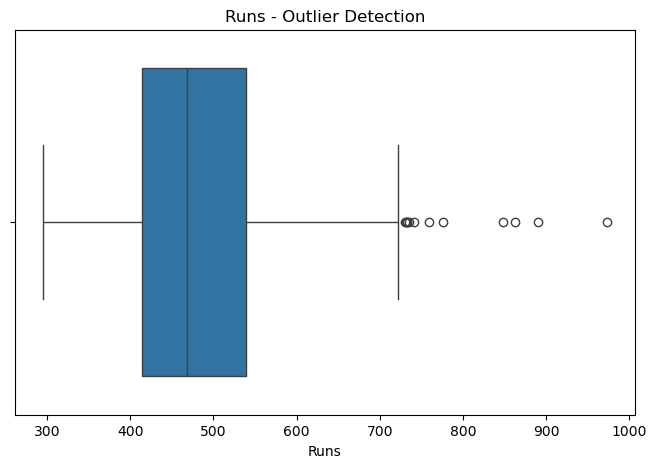

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Runs"]
)

plt.title("Runs - Outlier Detection")

plt.show()

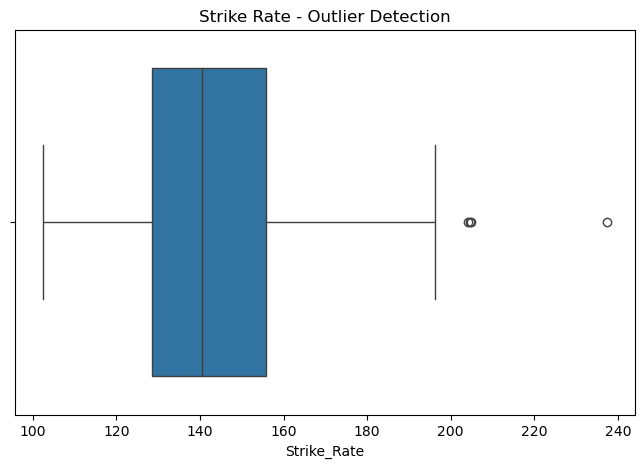

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Strike_Rate"]
)

plt.title("Strike Rate - Outlier Detection")

plt.show()

In [60]:
Q1 = df["Runs"].quantile(0.25)

Q3 = df["Runs"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

print("Lower:", lower_limit)

print("Upper:", upper_limit)

Lower: 226.5
Upper: 726.5


In [61]:
runs_outliers = df[
    (df["Runs"] < lower_limit) |
    (df["Runs"] > upper_limit)
]

runs_outliers

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season
60,Chris Gayle,15,14,733,61.08,160.75,46,59,2012
75,Michael Hussey,17,17,733,52.36,129.51,81,17,2013
120,Virat Kohli,16,16,973,81.08,152.03,83,38,2016
121,David Warner,17,17,848,60.57,151.43,88,31,2016
150,Kane Williamson,17,17,735,52.50,142.44,63,28,2018
210,Jos Buttler,17,17,863,57.53,149.05,83,45,2022
225,Shubman Gill,17,17,890,59.33,157.80,85,33,2023
226,Faf du Plessis,14,14,730,56.15,153.68,60,36,2023
240,Virat Kohli,15,15,741,61.75,154.70,62,38,2024
255,Sai Sudharsan,15,15,759,54.21,156.17,88,21,2025


In [62]:
df.to_csv(
    "ipl_cleaned_data.csv",
    index=False
)

## Univariate Analysis

In [63]:
df["Runs"].mean()

np.float64(489.659649122807)

In [64]:
df["Runs"].median()

468.0

In [65]:
df["Runs"].mode()

0    418
Name: Runs, dtype: int64

In [66]:
df["Runs"].std()

106.84597947916605

In [67]:
df["Runs"].var()

11416.063330862371

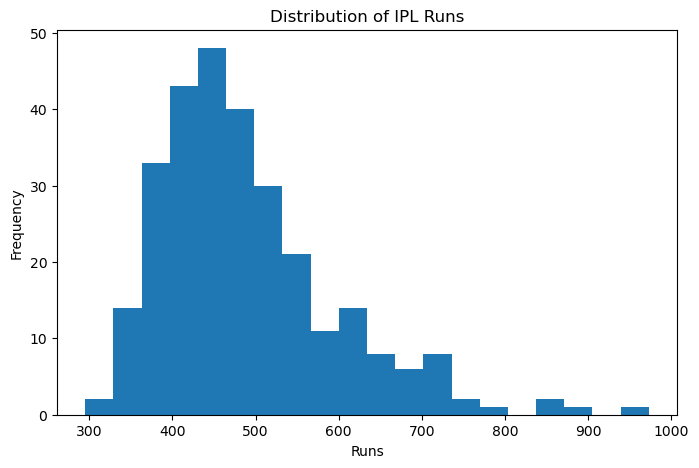

In [68]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Runs"],
    bins=20
)

plt.xlabel("Runs")

plt.ylabel("Frequency")

plt.title("Distribution of IPL Runs")

plt.show()

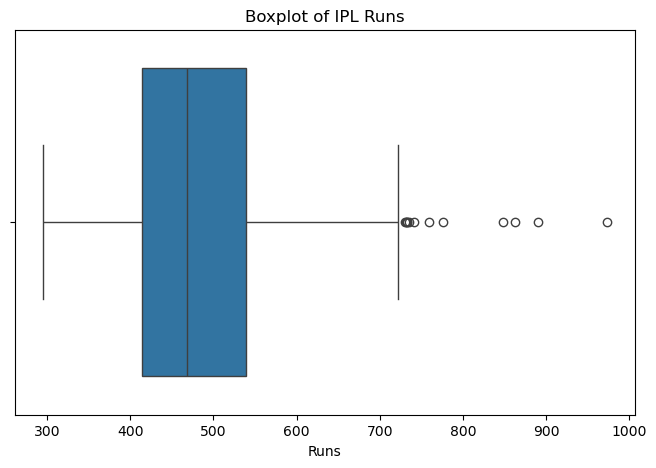

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Runs"]
)

plt.title("Boxplot of IPL Runs")

plt.show()

In [70]:
df["Season"].value_counts().sort_index()

Season
2008    15
2009    15
2010    15
2011    15
2012    15
2013    15
2014    15
2015    15
2016    15
2017    15
2018    15
2019    15
2020    15
2021    15
2022    15
2023    15
2024    15
2025    15
2026    15
Name: count, dtype: int64

In [71]:
df["Player"].value_counts().head(20)

Player
Virat Kohli         12
Suresh Raina        11
Shikhar Dhawan      11
Rohit Sharma        10
KL Rahul             9
David Warner         8
Faf du Plessis       7
AB de Villiers       7
Robin Uthappa        7
MS Dhoni             7
Shubman Gill         6
Suryakumar Yadav     5
Ajinkya Rahane       5
Rishabh Pant         5
Sanju Samson         5
Shreyas Iyer         5
Virender Sehwag      5
Chris Gayle          5
Abhishek Sharma      4
Jos Buttler          4
Name: count, dtype: int64

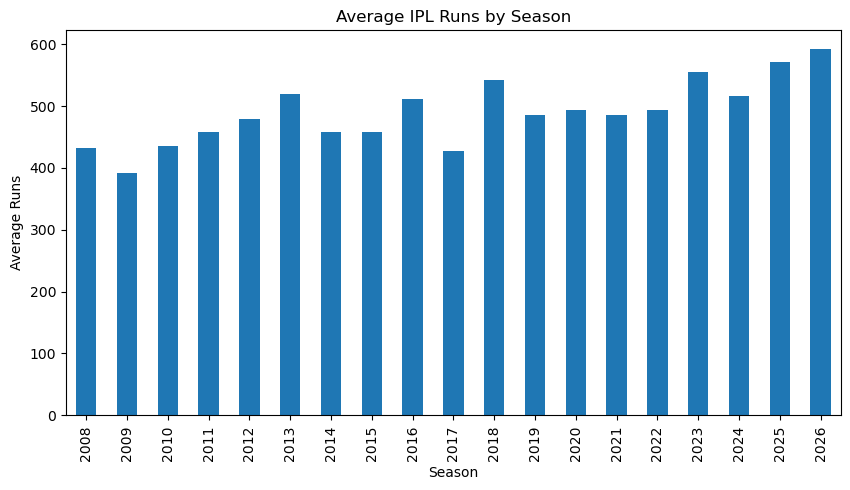

In [72]:
season_average = (
    df.groupby("Season")["Runs"]
    .mean()
)

plt.figure(figsize=(10,5))

season_average.plot(
    kind="bar"
)

plt.xlabel("Season")

plt.ylabel("Average Runs")

plt.title("Average IPL Runs by Season")

plt.show()

In [73]:
df.groupby("Season")["Runs"].mean()

Season
2008    431.533333
2009    391.866667
2010    435.200000
2011    457.533333
2012    478.200000
2013    518.666667
2014    458.533333
2015    457.733333
2016    511.866667
2017    426.800000
2018    542.066667
2019    485.800000
2020    493.533333
2021    484.800000
2022    493.400000
2023    555.600000
2024    516.400000
2025    571.266667
2026    592.733333
Name: Runs, dtype: float64

In [74]:
df.groupby("Season")["Runs"].agg(
    [
        "mean",
        "median",
        "max",
        "min"
    ]
)

,mean,median,max,min
Season,,,,
2008,431.533333,421.0,616,320
2009,391.866667,365.0,572,295
2010,435.200000,419.0,618,356
2011,457.533333,434.0,608,383
2012,478.200000,441.0,733,371
2013,518.666667,488.0,733,418
2014,458.533333,410.0,660,376
2015,457.733333,439.0,562,372
2016,511.866667,453.0,973,357


In [75]:
crosstab = pd.crosstab(
    df["Season"],
    df["Player"]
)

crosstab

Player,AB de Villiers,Aaron Finch,Abhishek Sharma,Adam Gilchrist,Aiden Markram,Ajinkya Rahane,Ambati Rayudu,Andre Russell,Andrew Symonds,Brad Hodge,...,Suresh Raina,Suryakumar Yadav,Tillakaratne Dilshan,Travis Head,Vaibhav Sooryavanshi,Virat Kohli,Virender Sehwag,Yashasvi Jaiswal,Yusuf Pathan,Yuvraj Singh
Season,,,,,,,,,,,,,,,,,,,,,
2008,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,1,0
2009,1,0,0,1,0,0,0,0,0,1,...,1,0,1,0,0,0,0,0,0,1
2010,0,0,0,0,0,0,1,0,1,0,...,1,0,0,0,0,0,1,0,0,0
2011,0,0,0,1,0,0,1,0,0,0,...,1,0,0,0,0,1,1,0,0,0
2012,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
2013,0,1,0,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
2014,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,1
2015,1,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
2016,1,1,0,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0


In [76]:
correlation = df[
    [
        "Matches",
        "Innings",
        "Runs",
        "Average",
        "Strike_Rate",
        "Fours",
        "Sixes"
    ]
].corr()

correlation

,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes
Matches,1.000000,0.926725,0.189434,-0.211267,-0.090219,0.092537,0.043214
Innings,0.926725,1.000000,0.282490,-0.255863,-0.112588,0.228836,0.049970
Runs,0.189434,0.282490,1.000000,0.606781,0.347530,0.763379,0.549386
Average,-0.211267,-0.255863,0.606781,1.000000,0.314560,0.289298,0.438104
Strike_Rate,-0.090219,-0.112588,0.347530,0.314560,1.000000,0.134352,0.767814
Fours,0.092537,0.228836,0.763379,0.289298,0.134352,1.000000,0.084924
Sixes,0.043214,0.049970,0.549386,0.438104,0.767814,0.084924,1.000000


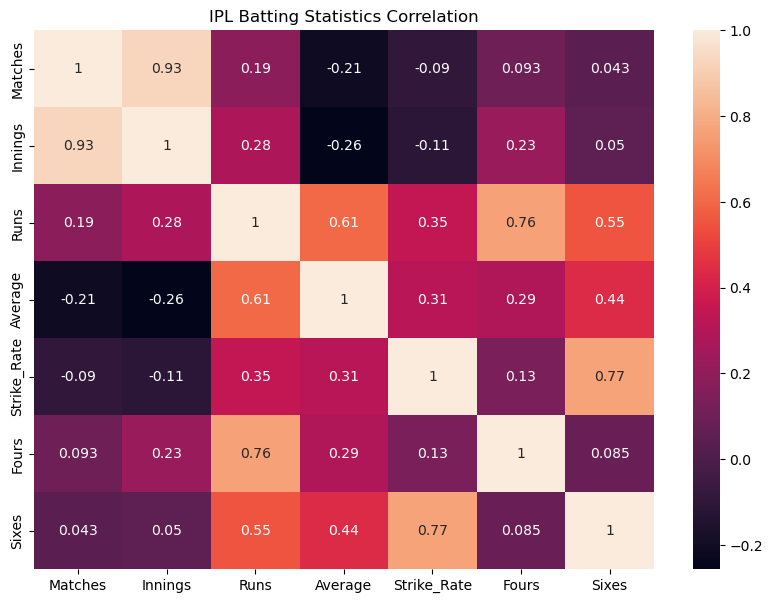

In [77]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("IPL Batting Statistics Correlation")

plt.show()

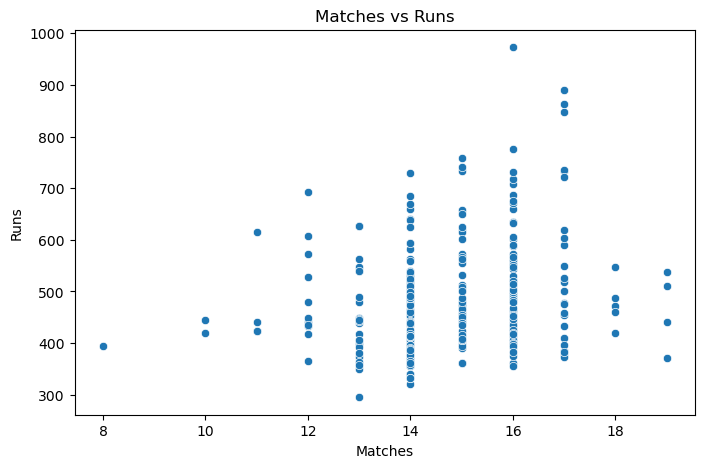

In [78]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Matches",
    y="Runs"
)

plt.xlabel("Matches")

plt.ylabel("Runs")

plt.title("Matches vs Runs")

plt.show()

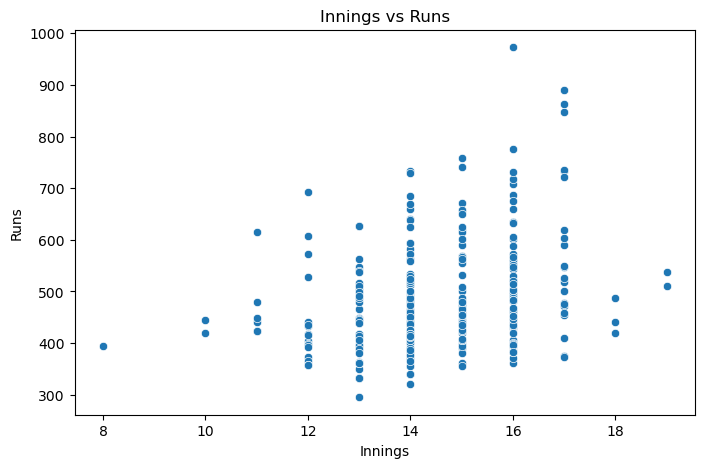

In [79]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Innings",
    y="Runs"
)

plt.xlabel("Innings")

plt.ylabel("Runs")

plt.title("Innings vs Runs")

plt.show()

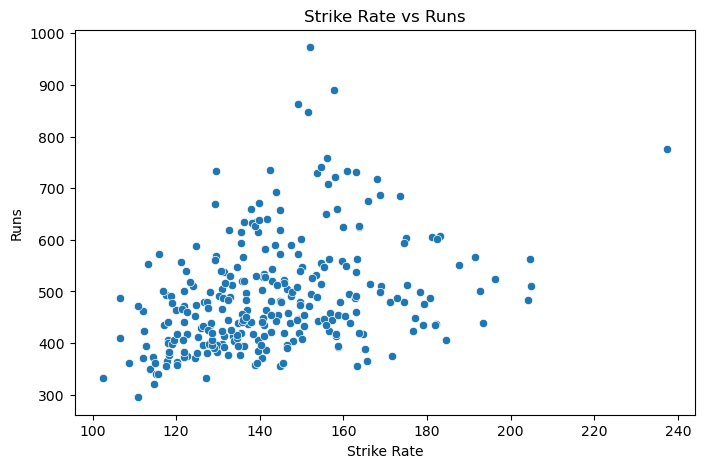

In [80]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Strike_Rate",
    y="Runs"
)

plt.xlabel("Strike Rate")

plt.ylabel("Runs")

plt.title("Strike Rate vs Runs")

plt.show()

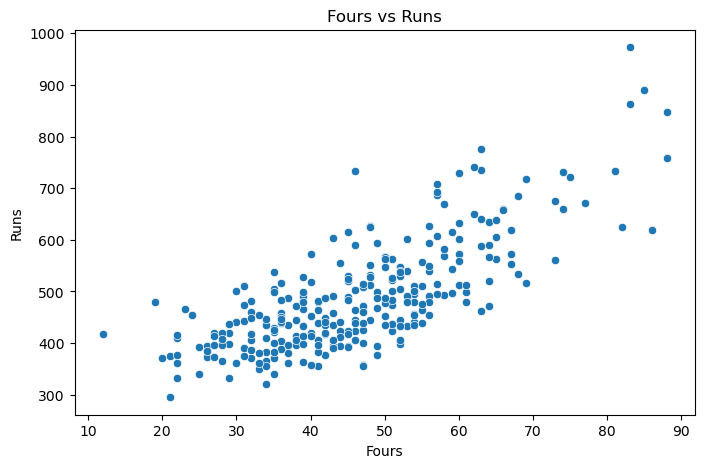

In [81]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Fours",
    y="Runs"
)

plt.xlabel("Fours")

plt.ylabel("Runs")

plt.title("Fours vs Runs")

plt.show()

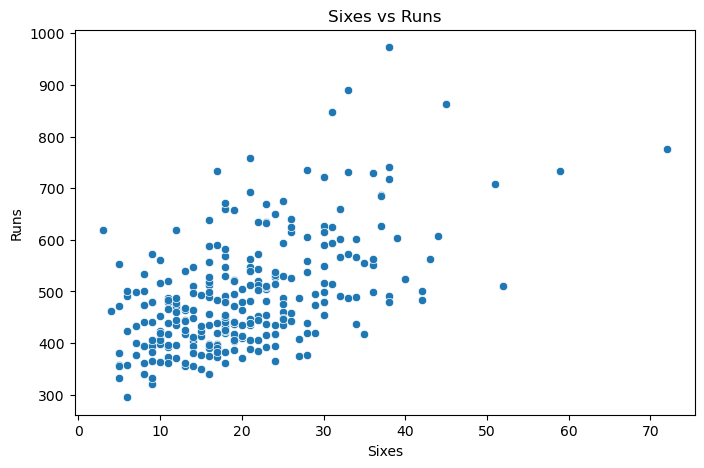

In [82]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Sixes",
    y="Runs"
)

plt.xlabel("Sixes")

plt.ylabel("Runs")

plt.title("Sixes vs Runs")

plt.show()

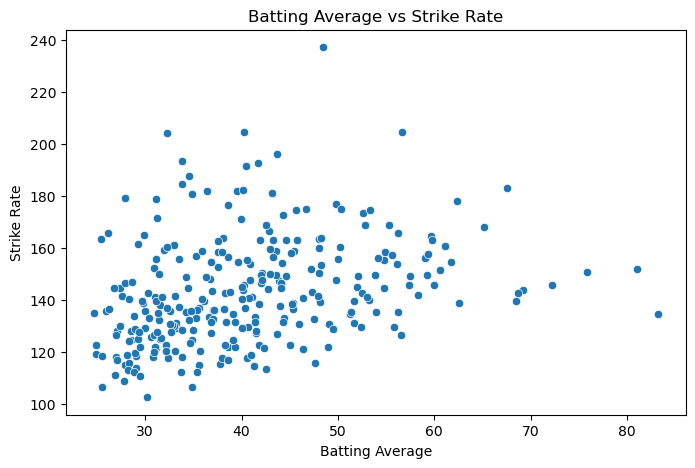

In [83]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Average",
    y="Strike_Rate"
)

plt.xlabel("Batting Average")

plt.ylabel("Strike Rate")

plt.title("Batting Average vs Strike Rate")

plt.show()

In [84]:
print("Final rows:", df.shape[0])

print("Final columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Final rows: 285
Final columns: 9

Column names:
['Player', 'Matches', 'Innings', 'Runs', 'Average', 'Strike_Rate', 'Fours', 'Sixes', 'Season']

Missing values:
Player         0
Matches        0
Innings        0
Runs           0
Average        0
Strike_Rate    0
Fours          0
Sixes          0
Season         0
dtype: int64

Duplicate rows:
0


In [85]:
df.to_csv(
    "IPL_Final_Cleaned_Data.csv",
    index=False
)

print("Final CSV saved successfully")

Final CSV saved successfully


### To analyze IPL batsmen performance across different IPL seasons using batting statistics such as matches, innings, runs, batting average, strike rate, fours and sixes, and identify patterns and relationships among these variables.

In [86]:
df

,Player,Matches,Innings,Runs,Average,Strike_Rate,Fours,Sixes,Season
0,Shaun Marsh,11,11,616,68.44,139.68,59,26,2008
1,Gautam Gambhir,14,14,534,41.08,140.90,68,8,2008
2,Sanath Jayasuriya,14,14,514,42.83,166.34,57,31,2008
3,Shane Watson,15,15,472,47.20,151.77,47,19,2008
4,Graeme Smith,11,11,441,49.00,121.82,54,8,2008
...,...,...,...,...,...,...,...,...,...
280,Dhruv Jurel,16,16,515,36.79,154.65,47,24,2026
281,Prabhsimran Singh,14,13,510,42.50,168.87,55,23,2026
282,Rajat Patidar,15,14,501,41.75,192.69,30,42,2026
283,Shreyas Iyer,14,13,498,55.33,168.81,39,30,2026
